# Limpeza de outliers de quilometragem (KM)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RAW_PATH = "../data/raw/vin_share.zip"
PROCESSED_PATH = "../data/processed/vin_share_km_clean.parquet"

## 1. Carregamento dos dados

Base bruta de manutenções por VIN (`vin_share.zip`), 25 colunas. A coluna de interesse é `KM`, a quilometragem registrada no serviço.

In [2]:
df = pd.read_csv(RAW_PATH, compression="zip", low_memory=False)
print("Linhas:", len(df), "| Colunas:", df.shape[1])
df[["VIN_Hash", "ModelName", "ModelYear", "ServiceDate", "KM"]].head()

Linhas: 602788 | Colunas: 25


,VIN_Hash,ModelName,ModelYear,ServiceDate,KM
0,0f72d6862a562100b701c5426fa4e30c63721e31981e67...,TRANSIT,"2,023.00",10/07/2023,"20,135.00"
1,6ab46c8486b5724f108c8c941d49755f88892d6d84fede...,MAVERICK,"2,023.00",10/14/2023,"9,857.00"
2,14c9676c1b566c5b8ee957653a54d1b4af40127243ea5d...,MAVERICK,"2,022.00",10/20/2023,"10,605.00"
3,ef733062d088860950c1fc9d5bf135cfbe5607d1712f7a...,TRANSIT,"2,023.00",10/27/2023,"38,966.00"
4,0b8ea33b5f263b87eec796d9e296948da5fe0a99e562aa...,TRANSIT,"2,023.00",11/23/2023,"3,755.00"


## 2. Visão geral da distribuição de KM

Estatísticas básicas, nulos e valores degenerados (negativos/zero) antes de qualquer tratamento.

In [3]:
km = df["KM"]

print("Nulos:", km.isna().sum())
print("Negativos:", (km < 0).sum())
print("Zeros:", (km == 0).sum())
print()
print(km.describe())
print()
for p in [0.5, 0.9, 0.95, 0.99, 0.995, 0.999, 0.9999]:
    print(f"percentil {p:>7}: {km.quantile(p):>15,.0f}")

Nulos: 2541
Negativos: 0
Zeros: 47

count       600,247.00
mean         40,026.87
std       1,749,348.75
min               0.00
25%          14,768.00
50%          28,101.00
75%          48,194.00
max     955,388,451.00
Name: KM, dtype: float64

percentil     0.5:          28,101
percentil     0.9:          72,580
percentil    0.95:          95,272
percentil    0.99:         145,724
percentil   0.995:         169,632
percentil   0.999:         228,200
percentil  0.9999:         711,293


### 2.1 Estatísticas descritivas completas

In [4]:
def km_descriptive_stats(s: pd.Series, s_full: pd.Series | None = None) -> pd.Series:
    """Estatísticas descritivas de uma série de KM. `s_full` (com nulos) é opcional, só para contar nulos."""
    s_valid = s.dropna()
    s_ref = s_full if s_full is not None else s
    return pd.Series({
        "n": s_valid.count(),
        "nulos": s_ref.isna().sum(),
        "media": s_valid.mean(),
        "mediana": s_valid.median(),
        "moda": s_valid.mode().iloc[0],
        "desvio_padrao": s_valid.std(),
        "variancia": s_valid.var(),
        "coef_variacao": s_valid.std() / s_valid.mean(),
        "minimo": s_valid.min(),
        "maximo": s_valid.max(),
        "amplitude": s_valid.max() - s_valid.min(),
        "q1": s_valid.quantile(0.25),
        "q3": s_valid.quantile(0.75),
        "iqr": s_valid.quantile(0.75) - s_valid.quantile(0.25),
        "assimetria_skew": s_valid.skew(),
        "curtose_kurtosis": s_valid.kurtosis(),
    })


km_valid = km.dropna()
km_descriptive_stats(km).to_frame(name="KM")

,KM
n,"600,247.00"
nulos,"2,541.00"
media,"40,026.87"
mediana,"28,101.00"
moda,"10,998.00"
desvio_padrao,"1,749,348.75"
variancia,"3,060,221,036,946.23"
coef_variacao,43.70
minimo,0.00
maximo,"955,388,451.00"


Coeficiente de variação bem acima de 1 e assimetria/curtose extremamente altas confirmam uma cauda direita pesada — consistente com os outliers de km identificados na Seção 3.

C:\Users\bruno\AppData\Local\Temp\ipykernel_14212\1483817550.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[2].boxplot(km.dropna(), vert=True)


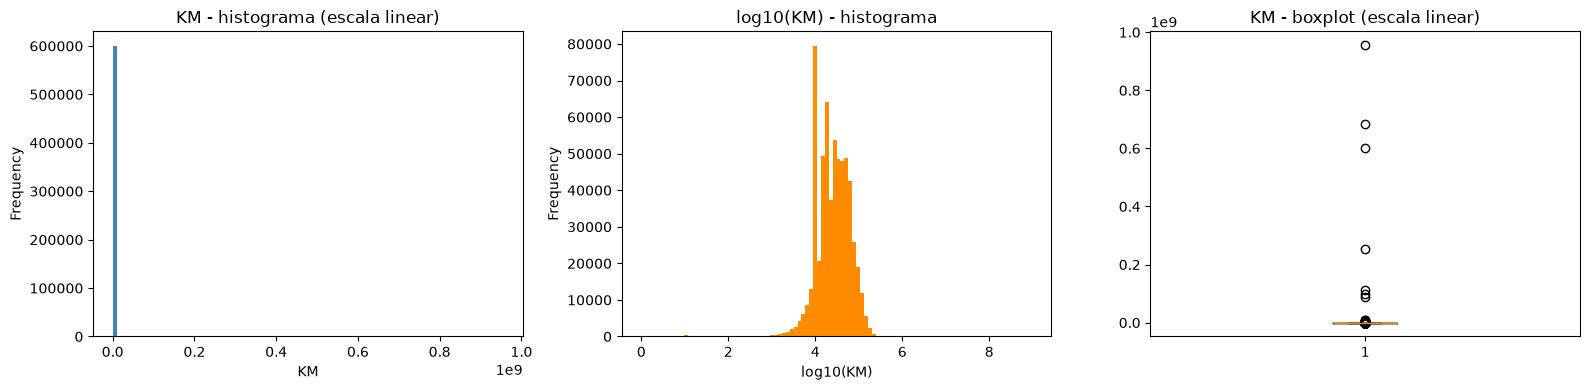

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

km.dropna().plot(kind="hist", bins=100, ax=axes[0], color="steelblue")
axes[0].set_title("KM - histograma (escala linear)")
axes[0].set_xlabel("KM")

np.log10(km.dropna().clip(lower=1)).plot(kind="hist", bins=100, ax=axes[1], color="darkorange")
axes[1].set_title("log10(KM) - histograma")
axes[1].set_xlabel("log10(KM)")

axes[2].boxplot(km.dropna(), vert=True)
axes[2].set_title("KM - boxplot (escala linear)")

plt.tight_layout()
plt.show()

## 3. Detecção de outliers

### 3.1 Método IQR (clássico)

Testamos primeiro o método padrão de 1.5×IQR acima do 3º quartil.

In [6]:
q1, q3 = km.quantile(0.25), km.quantile(0.75)
iqr = q3 - q1
iqr_upper = q3 + 1.5 * iqr

n_outliers_iqr = (km > iqr_upper).sum()
print(f"Q1={q1:,.0f}  Q3={q3:,.0f}  IQR={iqr:,.0f}")
print(f"Limite superior (Q3 + 1.5*IQR): {iqr_upper:,.0f}")
print(f"Linhas acima do limite: {n_outliers_iqr:,} ({n_outliers_iqr / len(km):.1%})")

Q1=14,768  Q3=48,194  IQR=33,426
Limite superior (Q3 + 1.5*IQR): 98,333
Linhas acima do limite: 28,436 (4.7%)


O IQR classifica ~4-5% das linhas como outlier acima de ~98 mil km — mas o percentil 95 real da base já é ~95 mil km. Ou seja, o método descartaria carros de alta quilometragem legítimos (comum em frotas/táxis), porque a distribuição de KM é naturalmente assimétrica à direita. IQR não é adequado aqui.

### 3.2 Abordagem por percentil + corte de sanidade de domínio

Em vez de IQR, usamos:
- **Corte de sanidade**: valores fisicamente implausíveis (ex.: > 1.000.000 km em um serviço) são erros de digitação/sistema, não outliers estatísticos — são removidos.
- **Winsorização no p99.5**: entre o corte de sanidade e o p99.5, os valores são mantidos, mas o extremo superior é limitado (capped) no p99.5 para reduzir a influência de caudas longas sem descartar veículos de alta km legítimos.

In [7]:
SANITY_MAX_KM = 1_000_000

print("Acima de 500 mil km:", (km > 500_000).sum())
print(f"Acima do corte de sanidade ({SANITY_MAX_KM:,} km):", (km > SANITY_MAX_KM).sum())
df.loc[km > SANITY_MAX_KM, ["VIN_Hash", "ModelName", "ModelYear", "ServiceDate", "KM"]].sort_values("KM", ascending=False).head(10)

Acima de 500 mil km: 105
Acima do corte de sanidade (1,000,000 km): 41


,VIN_Hash,ModelName,ModelYear,ServiceDate,KM
323701,b987de46215537070b8883fa7d5d7680d05490b4baaa1f...,ECOSPORT,"2,021.00",11/30/2023,"955,388,451.00"
564887,74bd3409300a69197cdcaf73281b0dc08501833ea7e23e...,ECOSPORT,"2,020.00",2/17/2023,"683,412,521.00"
273453,a7b15a3a4749e993bb1ed20e536c5a92f8e99cc9a2ed7f...,RANGER,"2,020.00",7/28/2022,"602,243,070.00"
214223,b45cefd2e8e0abdacefcccb8ac4ddef5f9c40c83d37826...,RANGER,"2,021.00",04/04/2023,"252,633,248.00"
118171,2e75d244c577f57a33a3e60816c95763e0f125081af25f...,RANGER,"2,022.00",2/16/2023,"111,111,111.00"
223366,8c0e48fe8e44a3e6d1035da18ecc023d16d33fdde1fdeb...,KA,"2,021.00",12/28/2023,"96,969,696.00"
185543,19c8d772745fb74da73d8d19de6265cebf47837971e8a9...,RANGER,"2,023.00",9/19/2023,"89,348,934.00"
10569,3c484df52690614b0795052843e79dc31933b90b184e20...,BRONCO SPORT,"2,021.00",02/09/2026,"9,876,543.00"
38839,3ba903b9e7c5c19b62ff679f15abe3a3c920a4897619f6...,KA,"2,021.00",03/04/2022,"7,692,553.00"
403740,ee9141ddd08c813fed39fe0abfed60822e346228f25c8b...,RANGER,"2,023.00",7/31/2025,"7,191,010.00"


## 4. Estratégia de limpeza aplicada

1. Linhas com `KM` nulo → mantidas no dataset, mas sinalizadas (`km_is_null`), pois a ausência pode ser informativa (não imputamos aqui).
2. Linhas com `KM > SANITY_MAX_KM` (1.000.000) → removidas (erro de sistema/digitação).
3. Valores remanescentes acima do p99.5 → *winsorizados* (capados) no p99.5, guardando o valor original em `KM_original` para auditoria.

In [8]:
df_clean = df.copy()

df_clean["km_is_null"] = df_clean["KM"].isna()

n_before = len(df_clean)
df_clean = df_clean.loc[df_clean["KM"].isna() | (df_clean["KM"] <= SANITY_MAX_KM)].copy()
n_removed_sanity = n_before - len(df_clean)

p995 = df_clean["KM"].quantile(0.995)
df_clean["KM_original"] = df_clean["KM"]
n_capped = (df_clean["KM"] > p995).sum()
df_clean["KM"] = df_clean["KM"].clip(upper=p995)

print(f"Linhas antes: {n_before:,}")
print(f"Removidas pelo corte de sanidade: {n_removed_sanity:,}")
print(f"Capadas no p99.5 ({p995:,.0f} km): {n_capped:,}")
print(f"Linhas depois: {len(df_clean):,}")

Linhas antes: 602,788
Removidas pelo corte de sanidade: 41
Capadas no p99.5 (169,366 km): 3,000
Linhas depois: 602,747


### 4.1 Estatísticas descritivas após a limpeza

Mesmas métricas da Seção 2.1, recalculadas em `KM` depois da remoção de outliers de sanidade e da winsorização no p99.5, lado a lado com os valores originais.

In [9]:
comparativo = pd.DataFrame({
    "antes": km_descriptive_stats(km),
    "depois": km_descriptive_stats(df_clean["KM"]),
})
comparativo

,antes,depois
n,"600,247.00","600,206.00"
nulos,"2,541.00","2,541.00"
media,"40,026.87","34,995.01"
mediana,"28,101.00","28,097.00"
moda,"10,998.00","169,366.00"
desvio_padrao,"1,749,348.75","29,417.04"
variancia,"3,060,221,036,946.23","865,362,518.58"
coef_variacao,43.70,0.84
minimo,0.00,0.00
maximo,"955,388,451.00","169,366.00"


Coeficiente de variação caiu de 43,7 para 0,84 e a assimetria/curtose ficaram em níveis normais (perto de uma distribuição bem comportada). A moda pós-limpeza migrou para o valor do teto (169.366) — efeito esperado da winsorização, já que todos os valores acima do p99.5 são empilhados exatamente nesse ponto.

## 5. Validação visual da distribuição de KM antes/depois da limpeza

Histogramas e boxplots lado a lado para confirmar visualmente que a cauda pesada foi controlada sem descaracterizar o corpo da distribuição.

C:\Users\bruno\AppData\Local\Temp\ipykernel_14212\2335884325.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 0].boxplot(km.dropna(), vert=False)
C:\Users\bruno\AppData\Local\Temp\ipykernel_14212\2335884325.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(df_clean["KM"].dropna(), vert=False)


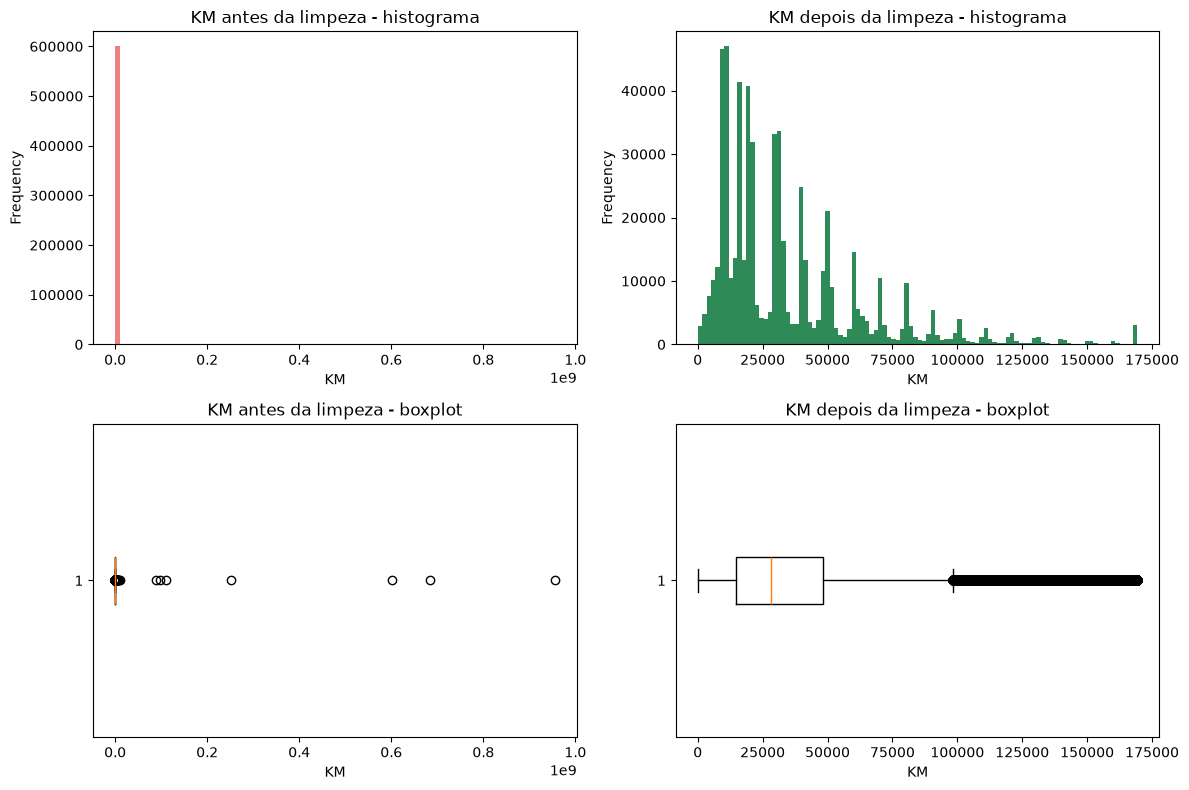

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

km.dropna().plot(kind="hist", bins=100, ax=axes[0, 0], color="lightcoral")
axes[0, 0].set_title("KM antes da limpeza - histograma")
axes[0, 0].set_xlabel("KM")

df_clean["KM"].dropna().plot(kind="hist", bins=100, ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("KM depois da limpeza - histograma")
axes[0, 1].set_xlabel("KM")

axes[1, 0].boxplot(km.dropna(), vert=False)
axes[1, 0].set_title("KM antes da limpeza - boxplot")
axes[1, 0].set_xlabel("KM")

axes[1, 1].boxplot(df_clean["KM"].dropna(), vert=False)
axes[1, 1].set_title("KM depois da limpeza - boxplot")
axes[1, 1].set_xlabel("KM")

plt.tight_layout()
plt.show()

## 6. Salvando o dataset limpo

Grava em `backend/data/processed/`, mantendo `KM_original` e `km_is_null` para rastreabilidade.

In [11]:
import pathlib

pathlib.Path(PROCESSED_PATH).parent.mkdir(parents=True, exist_ok=True)
df_clean.to_parquet(PROCESSED_PATH, index=False)
print("Salvo em:", PROCESSED_PATH)

Salvo em: ../data/processed/vin_share_km_clean.parquet
